In [13]:
!pip install -q seaborn aeon

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dehb 0.1.2 requires numpy<2.0,>=1.18.2, but you have numpy 2.3.5 which is incompatible.
gluonts 0.16.2 requires numpy<2.2,>=1.16, but you have numpy 2.3.5 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

pd.set_option('display.max_rows', 2000)
pd.set_option('display.max_columns', 200)

c:\Users\poehlmann\PycharmProjects\DUESEnBench\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data from DB and average across seeds

In [2]:
db_path = "../results.db"

# For Repeating the illustrative study uncomment one of the following lines to include only the datasets used in the study. + uncomment df = df[df["dataset"].isin(ds_to_include)]
# ds_to_include = ["spiketrains", "taobao_easytpp", "taxi_easytpp"] # RMTPP
# ds_to_include = ["911", "amazon_easytpp", "hawkes_1", "hawkes_dependent", "taxi_nyc_neighborhoods"] # THP
# ds_to_include = ["hawkes_1", "volcano_easytpp", "synthea"] # S2P2
# ds_to_include = ["crypto_transactions", "earthquake", "hawkes_dependent", "spiketrains", "stackoverflow", "taxi_nyc_neighborhoods"] # SAHP

conn = sqlite3.connect(db_path)
df = pd.read_sql(f"""
SELECT 
    dataset,
    model,
    AVG(test_acc)      AS avg_test_acc,
    AVG(test_rmse)     AS avg_test_rmse,
    AVG(test_f1_macro) AS avg_test_f1_macro,
    AVG(inference_duration) AS avg_inference_duration,
    AVG(test_smape) AS avg_smape
FROM final_results
GROUP BY dataset, model;
""", conn)
conn.close()

# df = df[df["dataset"].isin(ds_to_include)]
df

,dataset,model,avg_test_acc,avg_test_rmse,avg_test_f1_macro,avg_inference_duration,avg_smape
0,911,NHP,0.561150,0.123785,0.239631,15.255131,1.058716
1,911,RMTPP,0.560701,0.119678,0.242127,1.803711,1.055339
2,911,S2P2,0.560126,0.134088,0.281602,2.117842,1.046722
3,911,SAHP,0.561269,0.126506,0.240234,1.952245,1.064231
4,911,THP,0.562110,0.117849,0.251034,2.053237,1.049842
5,amazon_easytpp,NHP,0.306905,0.488331,0.121203,7.054850,0.917155
6,amazon_easytpp,RMTPP,0.297867,0.475497,0.044246,1.740633,1.030064
7,amazon_easytpp,S2P2,0.304044,6387.283603,0.055594,3.066868,1.316078
8,amazon_easytpp,SAHP,0.312513,0.533134,0.076717,2.119095,1.061528
9,amazon_easytpp,THP,0.339514,0.498130,0.129710,1.959750,1.059144


## Convert compute to ms/event

In [3]:
test_sizes = {
    "synthea": 433624 // 10,
    "crypto_transactions": 20832338 // 10,
    "earthquake": 91584 // 10,
    "volcano_easytpp": 8840 // 10,
    "taxi_easytpp": 74078 // 10,
    "taxi_nyc_neighborhoods": 62089613 // 10,
    "stackoverflow": 4361540 // 10,
    "retweet_easytpp": 2610102 // 10,
    "memetrack": 28611897 // 10,
    "wikipedia": 5920802 // 10,
    "amazon_easytpp": 413420 // 10,
    "taobao_easytpp": 113410 // 10,
    "human_activity": 6449 // 10,
    "mooc": 411749 // 10,
    "spiketrains": 842941 // 10,
    "911": 663522 // 10,
    "hawkes_1": 613058 // 10,
    "hawkes_dependent": 100829 // 10,
}

def to_ms_per_sample(row):
    test_n = test_sizes[row["dataset"]]
    return (row["avg_inference_duration"] * 1000) / test_n

df["ms_per_sample"] = df.apply(to_ms_per_sample, axis=1)


# Compute Normalized Error Metrics

In [4]:
import pandas as pd
import numpy as np

EPS = 1e-5

def compute_normalized_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["objective"] = (df["avg_test_acc"] - 0.2 * df["avg_smape"]) / 1.2

    metrics = {
        "avg_test_acc": "higher",
        "avg_test_rmse": "lower",
        "ms_per_sample": "lower",
        "objective": "higher",
        "ms_per_sample": "lower",
    }

    results = []
    valid_metrics_by_dataset = {}

    all_models = sorted(df["model"].unique())
    all_datasets = sorted(df["dataset"].unique())

    for dataset, g in df.groupby("dataset"):
        g = g.copy()
        norm_scores = {}
        valid_metrics = []

        for metric, direction in metrics.items():
            vals = g[metric]

            # skip constant 1.0 acc/f1 datasets
            if metric in ["avg_test_acc", "avg_test_f1_macro"] and np.allclose(vals, 1.0):
                continue

            valid_metrics.append(metric)

            if direction == "higher":
                topline = vals.max()
                baseline = vals.median()
                denom = max(topline - baseline, EPS)
                score = (topline - vals) / denom
            else:
                topline = vals.min()
                baseline = vals.median()
                denom = max(baseline - topline, EPS)
                score = (vals - topline) / denom

            norm_scores[metric] = score.clip(0, 1)

        valid_metrics_by_dataset[dataset] = valid_metrics

        for i, row in g.iterrows():
            entry = {
                "dataset": dataset,
                "model": row["model"],
            }
            for m in valid_metrics:
                entry[m] = norm_scores[m].loc[i]
            results.append(entry)

    norm_df = pd.DataFrame(results)

    # full dataset x model grid
    full_index = pd.MultiIndex.from_product(
        [all_datasets, all_models],
        names=["dataset", "model"]
    )
    norm_df = norm_df.set_index(["dataset", "model"]).reindex(full_index).reset_index()

    # fill missing evaluations with worst possible normalized value = 1
    # but only for metrics that are valid for that dataset
    for dataset, valid_metrics in valid_metrics_by_dataset.items():
        mask = norm_df["dataset"] == dataset
        for metric in valid_metrics:
            norm_df.loc[mask, metric] = norm_df.loc[mask, metric].fillna(1.0)

    # average across datasets per model
    overall = (
        norm_df
        .groupby("model", as_index=False)
        .mean(numeric_only=True)
    )
    overall["dataset"] = "Overall (Norm)"

    # align columns to original df
    cols = df.columns
    for col in cols:
        if col not in overall.columns:
            overall[col] = np.nan
    overall = overall[cols]

    return df, overall, norm_df

df_, overall, norm_df = compute_normalized_scores(df)
df = df_
norm_df

,dataset,model,avg_test_acc,avg_test_rmse,ms_per_sample,objective
0,911,NHP,1.000000,1.000000,1.000000,1.000000
1,911,RMTPP,1.000000,0.308182,0.000000,1.000000
2,911,S2P2,1.000000,1.000000,1.000000,0.542165
3,911,SAHP,0.876404,1.000000,0.595265,1.000000
4,911,THP,0.000000,0.000000,1.000000,0.000000
5,amazon_easytpp,NHP,1.000000,0.567059,1.000000,0.153265
6,amazon_easytpp,RMTPP,1.000000,0.000000,0.000000,1.000000
7,amazon_easytpp,S2P2,1.000000,1.000000,1.000000,1.000000
8,amazon_easytpp,SAHP,0.828021,1.000000,1.000000,1.000000
9,amazon_easytpp,THP,0.000000,1.000000,0.578968,0.000000


In [5]:
# Define Pretty Names for Datasets and Models

dataset_names = {
    "911": "911",
    "amazon_easytpp": "Amazon",
    "crypto_transactions": "Transactions",
    "earthquake": "Earthquakes",
    "hawkes_1": "Hawkes 1",
    "hawkes_dependent": "Hawkes Dep",
    "human_activity": "Human Activity",
    "memetrack": "MemeTrack",
    "mooc": "MOOC",
    "retweet_easytpp": "Retweets",
    "spiketrains": "Neural Spikes",
    "stackoverflow": "Stack Overflow",
    "synthea": "Synthea",
    "taobao_easytpp": "Taobao",
    "taxi_easytpp": "Taxi Boroughs",
    "taxi_nyc_neighborhoods": "Taxi NBHD",
    "volcano_easytpp": "Volcano",
    "wikipedia": "Wikipedia",
}

model_names = {
    "IntensityFree": "IFTPP",
    "RMTPP": "RMTPP",
    "SAHP": "SAHP",
    "ODETPP": "ODETPP",
    "S2P2": "S2P2",
    "THP": "THP",
    "NHP": "NHP",
}

# Results to Latex Table

In [7]:
from __future__ import annotations

from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
from matplotlib import cm


def df_to_latex_booktabs_transposed(
    df: pd.DataFrame,
    *,
    dataset_col: str = "dataset",
    model_col: str = "model",
    metric_cols: Sequence[str] = ("avg_test_acc", "avg_test_rmse", "avg_test_f1_macro"),
    metric_display_names: Mapping[str, str] | None = None,
    dataset_display_names: Mapping[str, str] | None = None,
    model_display_names: Mapping[str, str] | None = None,
    lower_is_better: Iterable[str] = ("avg_test_rmse",),
    float_fmt: str = ".3f",
    cmap_name: str = "magma",
    caption: str | None = None,
    label: str | None = None,
    table_env: bool = True,
    center: bool = True,
    na_rep: str = "--",
    zero_variation_tol: float = 1e-12,
    font_size_cmd: str = r"\scriptsize",
    arraystretch: float = 0.92,
    tabcolsep_pt: float = 3.2,
    tabrowsep_pt: float = 3.2,
    use_resizebox: bool = True,
    resize_to: str = r"\linewidth",
    dataset_vertical_rules: bool = False,
) -> str:
    """
    Layout:
        rows    = metrics grouped by dataset
        columns = models

    Features:
    - leftmost column: dataset name via \\multirow
    - second column: metric name
    - model columns on the right
    - remove metric rows with zero variation across models within a dataset
    - magma heatmap coloring per row
    - bold best value in each row
    - missing values shown as black cells with white '--'

    Required LaTeX packages:
        \\usepackage{booktabs}
        \\usepackage[table]{xcolor}
        \\usepackage{multirow}
        \\usepackage{array}
        \\usepackage{graphicx}   % if use_resizebox=True
        \\usepackage{colortbl}
    """
    required = {dataset_col, model_col, *metric_cols}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    metric_display_names = metric_display_names or {
        "avg_test_acc": "Acc",
        "avg_test_rmse": "RMSE",
        "avg_test_f1_macro": "F1",
        "objective": "Objective",
        "ms_per_sample": "Compute"
        
    }
    dataset_display_names = dataset_display_names or {}
    model_display_names = model_display_names or {}
    lower_is_better = set(lower_is_better)

    def latex_escape(text: object) -> str:
        s = str(text)
        replacements = {
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
            "\\": r"\textbackslash{}",
        }
        return "".join(replacements.get(ch, ch) for ch in s)

    def fmt(x: float) -> str:
        return format(float(x), float_fmt)

    def rgba_to_rgb255(rgba: tuple[float, float, float, float]) -> tuple[int, int, int]:
        r, g, b, _ = rgba
        return (
            int(round(255 * r)),
            int(round(255 * g)),
            int(round(255 * b)),
        )

    def luminance(rgb: tuple[int, int, int]) -> float:
        r, g, b = rgb
        return (0.2126 * r + 0.7152 * g + 0.0722 * b) / 255.0

    def text_color_for_bg(rgb: tuple[int, int, int]) -> str:
        return "black" if luminance(rgb) > 0.55 else "white"

    def best_mask(series: pd.Series, minimize: bool) -> pd.Series:
        valid = series.dropna()
        if valid.empty:
            return pd.Series(False, index=series.index)
        target = valid.min() if minimize else valid.max()
        return series.eq(target)

    def scores_01(series: pd.Series, minimize: bool) -> pd.Series:
        s = series.astype(float)
        valid = s.dropna()
        if valid.empty:
            return pd.Series(np.nan, index=s.index)

        vmin = valid.min()
        vmax = valid.max()

        if np.isclose(vmin, vmax, atol=zero_variation_tol):
            return pd.Series(0.5, index=s.index)

        if minimize:
            out = (vmax - s) / (vmax - vmin)
        else:
            out = (s - vmin) / (vmax - vmin)
        return out.clip(0.0, 1.0)

    def cell_tex(value: float | None, score: float | None, is_best: bool) -> str:
        if pd.isna(value):
            return rf"\cellcolor[HTML]{{000000}}\textcolor{{white}}{{{na_rep}}}"

        text = fmt(value)
        if is_best:
            text = rf"\textbf{{{text}}}"

        if score is None or pd.isna(score):
            return text

        rgb = rgba_to_rgb255(cmap(score))
        html = f"{rgb[0]:02X}{rgb[1]:02X}{rgb[2]:02X}"
        fg = text_color_for_bg(rgb)
        return rf"\cellcolor[HTML]{{{html}}}\textcolor{{{fg}}}{{{text}}}"

    # pivot: rows=(dataset, metric), cols=models
    pivot = (
        df[[dataset_col, model_col, *metric_cols]]
        .melt(
            id_vars=[dataset_col, model_col],
            value_vars=list(metric_cols),
            var_name="metric",
            value_name="value",
        )
        .pivot_table(
            index=[dataset_col, "metric"],
            columns=model_col,
            values="value",
            aggfunc="mean",
        )
    )

    dataset_order = list(dict.fromkeys(df[dataset_col].tolist()))
    model_order = list(dict.fromkeys(df[model_col].tolist()))
    pivot = pivot.reindex(columns=[m for m in model_order if m in pivot.columns])

    # Remove metric rows with zero variation across models within each dataset
    kept_rows: list[tuple[str, str]] = []
    kept_metrics_by_dataset: dict[str, list[str]] = {}

    for ds in dataset_order:
        metrics_here: list[str] = []
        for metric in metric_cols:
            idx = (ds, metric)
            if idx not in pivot.index:
                continue
            s = pivot.loc[idx].dropna()
            if s.empty:
                continue
            if np.isclose(s.max(), s.min(), atol=zero_variation_tol):
                continue
            metrics_here.append(metric)
            kept_rows.append(idx)
        if metrics_here:
            kept_metrics_by_dataset[ds] = metrics_here

    if not kept_rows:
        raise ValueError("All metric rows were removed due to zero variation or missing data.")

    pivot = pivot.loc[kept_rows]

    cmap = cm.get_cmap(cmap_name)

    score_map: dict[tuple[str, str], pd.Series] = {}
    best_map: dict[tuple[str, str], pd.Series] = {}

    for ds, metric in kept_rows:
        s = pivot.loc[(ds, metric)]
        minimize = metric in lower_is_better
        score_map[(ds, metric)] = scores_01(s, minimize=minimize)
        best_map[(ds, metric)] = best_mask(s, minimize=minimize)

    # column spec
    if dataset_vertical_rules:
        col_spec = "@{}ll@{}|@{}" + "r" * len(pivot.columns) + "@{}"
    else:
        col_spec = "@{}ll" + "r" * len(pivot.columns) + "@{}"

    lines: list[str] = []
    lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
    lines.append(rf"\setlength{{\aboverulesep}}{{{tabrowsep_pt}pt}}")
    lines.append(rf"\setlength{{\belowrulesep}}{{{tabrowsep_pt}pt}}")
    lines.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
    lines.append(rf"\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"\toprule")
    lines.append(r"\addlinespace[2pt]")

    header = ["Dataset", "Metric"] + [
        latex_escape(model_display_names.get(m, m)) for m in pivot.columns
    ]
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\midrule")

    for ds in dataset_order:
        metrics_here = kept_metrics_by_dataset.get(ds, [])
        if not metrics_here:
            continue

        pretty_ds = latex_escape(dataset_display_names.get(ds, ds))
        n_rows = len(metrics_here)

        for i, metric in enumerate(metrics_here):
            row_parts = []
            if i == 0:
                row_parts.append(rf"\multirow{{{n_rows}}}{{*}}{{{pretty_ds}}}")
            else:
                row_parts.append("")

            row_parts.append(latex_escape(metric_display_names.get(metric, metric)))

            for model in pivot.columns:
                val = pivot.loc[(ds, metric), model]
                score = score_map[(ds, metric)].loc[model]
                is_best = bool(best_map[(ds, metric)].loc[model])
                row_parts.append(cell_tex(val, score, is_best))

            lines.append(" & ".join(row_parts) + r" \\")
        lines.append(r"\midrule")

    if lines[-1] == r"\midrule":
        lines.pop()

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    inner = "\n".join(lines)

    out: list[str] = []
    if table_env:
        out.append(r"\begin{table}[t]")
        if center:
            out.append(r"\centering")
        if font_size_cmd:
            out.append(font_size_cmd)

    if use_resizebox:
        out.append(rf"\resizebox{{{resize_to}}}{{!}}{{%")
        out.append(inner)
        out.append("}")
    else:
        out.append(inner)

    if caption:
        out.append(rf"\caption{{{caption}}}")
    if label:
        out.append(rf"\label{{{label}}}")

    if table_env:
        out.append(r"\end{table}")

    return "\n".join(out)

## Raw Results

In [8]:
latex = df_to_latex_booktabs_transposed(
    df,
    dataset_display_names=dataset_names,
    model_display_names=model_names,
    caption="Main results across datasets.",
    label="tab:results_transposed",
    font_size_cmd=r"\tiny",
    tabcolsep_pt=2.0,
    tabrowsep_pt=0.0,
    lower_is_better=["avg_test_rmse", "ms_per_sample",],
    metric_cols=("avg_test_acc", "avg_test_rmse", "ms_per_sample", ),
    
    arraystretch=1.1,
)
print(latex)

\begin{table}[t]
\centering
\tiny
\resizebox{\linewidth}{!}{%
\setlength{\tabcolsep}{2.0pt}
\setlength{\aboverulesep}{0.0pt}
\setlength{\belowrulesep}{0.0pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{@{}llrrrrr@{}}
\toprule
\addlinespace[2pt]
Dataset & Metric & NHP & RMTPP & S2P2 & SAHP & THP \\
\midrule
\multirow{3}{*}{911} & Acc & \cellcolor[HTML]{BD3977}\textcolor{white}{0.561} & \cellcolor[HTML]{601880}\textcolor{white}{0.561} & \cellcolor[HTML]{000004}\textcolor{white}{0.560} & \cellcolor[HTML]{D5446D}\textcolor{white}{0.561} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.562}} \\
 & RMSE & \cellcolor[HTML]{E95462}\textcolor{white}{0.124} & \cellcolor[HTML]{FECA8D}\textcolor{black}{0.120} & \cellcolor[HTML]{000004}\textcolor{white}{0.134} & \cellcolor[HTML]{A8327D}\textcolor{white}{0.127} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.118}} \\
 & Compute & \cellcolor[HTML]{000004}\textcolor{white}{0.230} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.0

C:\Users\poehlmann\AppData\Local\Temp\ipykernel_43808\3474708462.py:196: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


## Normalized Results

In [9]:
latex = df_to_latex_booktabs_transposed(
    overall,
    dataset_display_names=dataset_names,
    model_display_names=model_names,
    caption="Main results across datasets.",
    label="tab:normalized_results",
    font_size_cmd=r"\tiny",
    tabcolsep_pt=2.0,
    tabrowsep_pt=0.0,
    lower_is_better=["avg_test_acc", "avg_test_rmse", "ms_per_sample", "objective"],
    metric_cols=("avg_test_acc", "avg_test_rmse", "ms_per_sample", "objective"),
    
    arraystretch=1.1,
)
print(latex)

\begin{table}[t]
\centering
\tiny
\resizebox{\linewidth}{!}{%
\setlength{\tabcolsep}{2.0pt}
\setlength{\aboverulesep}{0.0pt}
\setlength{\belowrulesep}{0.0pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{@{}llrrrrr@{}}
\toprule
\addlinespace[2pt]
Dataset & Metric & NHP & RMTPP & S2P2 & SAHP & THP \\
\midrule
\multirow{4}{*}{Overall (Norm)} & Acc & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.532}} & \cellcolor[HTML]{29115A}\textcolor{white}{0.803} & \cellcolor[HTML]{000004}\textcolor{white}{0.854} & \cellcolor[HTML]{D9466B}\textcolor{white}{0.665} & \cellcolor[HTML]{FEA16E}\textcolor{black}{0.596} \\
 & RMSE & \cellcolor[HTML]{B2357B}\textcolor{white}{0.751} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{0.595} & \cellcolor[HTML]{000004}\textcolor{white}{0.901} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.594}} & \cellcolor[HTML]{DC4869}\textcolor{white}{0.719} \\
 & Compute & \cellcolor[HTML]{000004}\textcolor{white}{0.947} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{

C:\Users\poehlmann\AppData\Local\Temp\ipykernel_43808\3474708462.py:196: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


# Critical Difference Diagrams

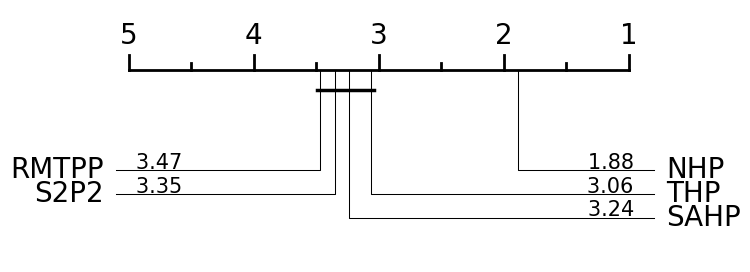

In [10]:
from aeon.visualisation import plot_critical_difference
from math import inf
import matplotlib.pyplot as plt

def adjust_fontsize_cd(plt, font_size, rank_font_size, tick_font_size, ticks_mod=1):
    # Get the current axes
    ax = plt.gca()

    # Increase padding between labels and axis
    ax.tick_params(axis='x', which='major', pad=20)

    # Adjust margins to provide more space for labels
    plt.subplots_adjust(bottom=0.1)

    # Optionally adjust y-axis label font size
    ax.tick_params(axis='y', labelsize=font_size)

    # Save and display the plot
    for txt in ax.texts:
        if txt.get_text().isdigit():   
            # Reduce Overcrowded X-Axis
            if int(txt.get_text()) % ticks_mod != 0 and (int(txt.get_text()) not in (len(classifiers), 1)):
                txt.set_visible(False)
            
            txt.set_fontsize(tick_font_size)
        else:
            # Round Rankings
            try: 
                value = float(txt.get_text())
                txt.set_text(f"   {value:.2f}   ")
                txt.set_fontsize(rank_font_size)
            except:
                txt.set_fontsize(font_size)
                pass


wide = df[df["dataset"]!="wikipedia"].pivot_table(
    index="dataset",
    columns="model",
    values="objective",
    aggfunc="mean"
)
wide = wide.fillna(-inf, axis=0)


scores = wide.to_numpy()
classifiers = wide.columns.tolist()


fig, _ = plot_critical_difference(
    scores, 
    classifiers, 
    lower_better=False,
    test='wilcoxon',  # wilcoxon or nemenyi
    correction='bonferroni', # or holm or none
    alpha=0.05,
    width=6,
    textspace=1,
)
adjust_fontsize_cd(plt, font_size=20, rank_font_size=15, tick_font_size=20, ticks_mod=1)
plt.savefig("figs/cd_diagram_objective.pdf", bbox_inches='tight')


# Correlation between Loglike and ACC/RMSE

In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(db_path)

query = """
SELECT dataset, loglike, acc, rmse
FROM trials
WHERE model = 'NHP' AND fidelity = 4
"""

df = pd.read_sql_query(query, conn)
conn.close()

In [12]:
def compute_corr(group):
    return pd.Series({
        "corr_loglike_acc": group["loglike"].corr(group["acc"]),
        "corr_loglike_rmse": group["loglike"].corr(group["rmse"])
    })

corr_df = df.groupby("dataset").apply(compute_corr).reset_index()
corr_df

c:\Users\poehlmann\PycharmProjects\DUESEnBench\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\poehlmann\PycharmProjects\DUESEnBench\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\poehlmann\AppData\Local\Temp\ipykernel_43808\62849945.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_df = df.groupby("dataset").apply(compute_corr).reset_index()


,dataset,corr_loglike_acc,corr_loglike_rmse
0,911,0.605815,-0.325154
1,amazon_easytpp,0.866307,0.320757
2,crypto_transactions,0.225570,-0.751218
3,earthquake,0.484957,-0.842493
4,hawkes_1,NaN,0.622916
5,hawkes_dependent,-0.290627,-0.007363
6,human_activity,0.779711,-0.095758
7,memetrack,0.215118,0.247397
8,mooc,0.405397,-0.543673
9,retweet_easytpp,0.262430,-0.350531


In [13]:
avg_corr = corr_df[[
    "corr_loglike_acc",
    "corr_loglike_rmse"
]].mean()

avg_row = pd.DataFrame([{
    "dataset": "AVG",
    "corr_loglike_acc": avg_corr["corr_loglike_acc"],
    "corr_loglike_rmse": avg_corr["corr_loglike_rmse"]
}])
final_df = pd.concat([corr_df, avg_row], ignore_index=True)
print(final_df.to_latex(index=False))

\begin{tabular}{lrr}
\toprule
dataset & corr_loglike_acc & corr_loglike_rmse \\
\midrule
911 & 0.605815 & -0.325154 \\
amazon_easytpp & 0.866307 & 0.320757 \\
crypto_transactions & 0.225570 & -0.751218 \\
earthquake & 0.484957 & -0.842493 \\
hawkes_1 & NaN & 0.622916 \\
hawkes_dependent & -0.290627 & -0.007363 \\
human_activity & 0.779711 & -0.095758 \\
memetrack & 0.215118 & 0.247397 \\
mooc & 0.405397 & -0.543673 \\
retweet_easytpp & 0.262430 & -0.350531 \\
spiketrains & 0.449292 & 0.025225 \\
stackoverflow & -0.531111 & -0.349895 \\
synthea & -0.388265 & -0.247483 \\
taobao_easytpp & 0.659053 & 0.852164 \\
taxi_easytpp & 0.618532 & 0.581080 \\
taxi_nyc_neighborhoods & 0.875349 & -0.753484 \\
volcano_easytpp & NaN & -0.215160 \\
wikipedia & NaN & NaN \\
AVG & 0.349169 & -0.107804 \\
\bottomrule
\end{tabular}



# Full Resource Consumption

In [14]:
conn = sqlite3.connect(db_path)
df = pd.read_sql(f"""
SELECT
    SUM(train_duration) AS total_train_duration,
    SUM(search_duration_once) AS total_search_duration,
    SUM(train_duration) + SUM(search_duration_once) AS total_resource_demand
FROM (
    SELECT
        dataset,
        model,
        SUM(train_duration) AS train_duration,
        MAX(search_duration) AS search_duration_once
    FROM final_results
    GROUP BY dataset, model
);
""", conn)
conn.close()
df

,total_train_duration,total_search_duration,total_resource_demand
0,680835.608907,711813.813988,1.392649e+06
